In [46]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("final_sql_mart.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.isna().sum())

      station_name   region    mode  measurement_count  avg_pressure  \
0    South Station    South  stress                  2         60.60   
1    South Station    South  normal                  1         57.30   
2    North Station    North  stress                  1         58.40   
3    North Station    North  normal                  2         54.65   
4  Central Station  Central  normal                  2         53.10   

   avg_flow  avg_temperature  avg_vibration  min_pressure  max_pressure  ...  \
0    130.95            74.75           3.30          60.2          61.0  ...   
1    125.00            71.60           2.70          57.3          57.3  ...   
2    127.00            72.30           2.90          58.4          58.4  ...   
3    120.95            68.55           2.15          54.2          55.1  ...   
4    118.75            67.40           1.85          52.8          53.4  ...   

   maintenance_count  total_duration  avg_severity  max_severity  alarm_share  \
0    

Top risk records

In [47]:
top_risk = df.sort_values("risk_score", ascending=False).head(10)

print(top_risk[["station_name", "region", "mode", "risk_score", "risk_level"]])

      station_name   region    mode  risk_score   risk_level
0    South Station    South  stress           4    high risk
1    South Station    South  normal           4    high risk
2    North Station    North  stress           4    high risk
3    North Station    North  normal           2  medium risk
4  Central Station  Central  normal           0     low risk
5     West Station     West  normal           0     low risk
6  Central Station  Central  repair           0     low risk
7     West Station     West  repair           0     low risk


In [48]:
high_risk = df[df["risk_level"] == "high risk"]
print("High risk rows:", high_risk.shape[0])

High risk rows: 3


In [49]:
risk_by_region = (
    df.groupby("region")["risk_score"]
    .mean()
    .sort_values(ascending=False)
)
print("Average risk score by region:")
print(risk_by_region)

Average risk score by region:
region
South      4.0
North      3.0
Central    0.0
West       0.0
Name: risk_score, dtype: float64


In [50]:
risk_by_mode = (
    df.groupby("mode")["risk_score"]
    .mean()
    .sort_values(ascending=False)
)
print("Average risk score by mode:")
print(risk_by_mode)

Average risk score by mode:
mode
stress    4.0
normal    1.5
repair    0.0
Name: risk_score, dtype: float64


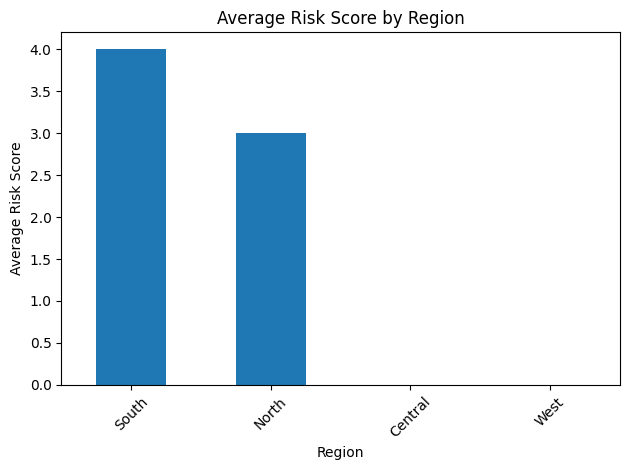

In [51]:
risk_by_region.plot(kind="bar")
plt.title("Average Risk Score by Region")
plt.xlabel("Region")
plt.ylabel("Average Risk Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

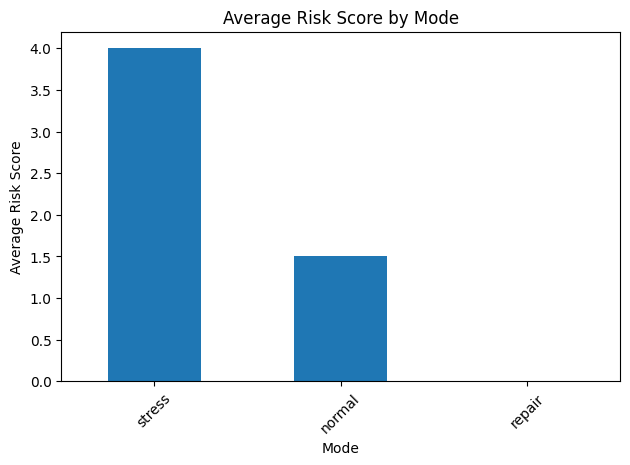

In [52]:
risk_by_mode.plot(kind="bar")
plt.title("Average Risk Score by Mode")
plt.xlabel("Mode")
plt.ylabel("Average Risk Score")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


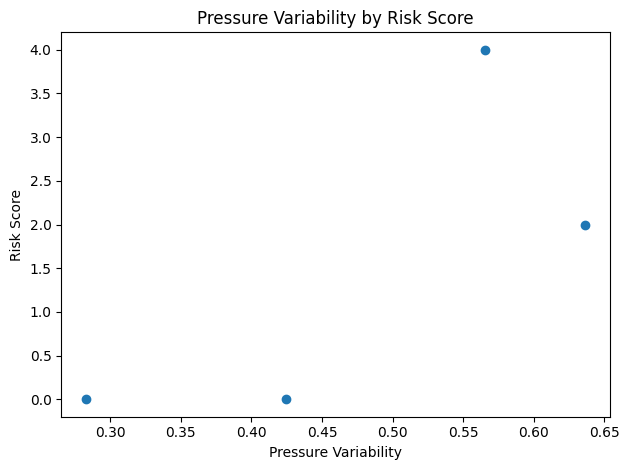

In [53]:
plt.scatter(df["pressure_std"],df["risk_score"])
plt.title("Pressure Variability by Risk Score")
plt.xlabel("Pressure Variability")
plt.ylabel("Risk Score")
plt.tight_layout()
plt.show()

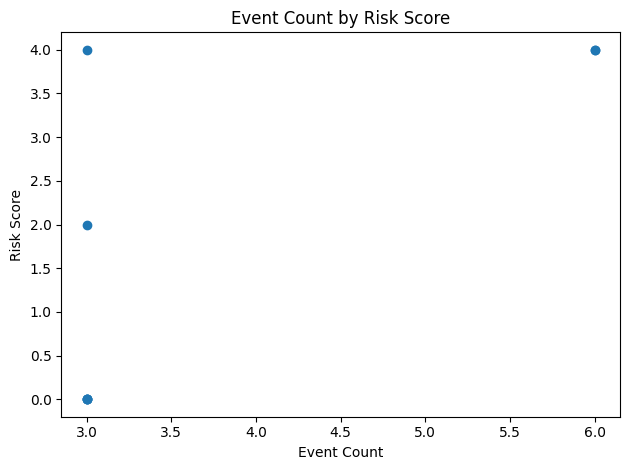

In [54]:
plt.scatter(df["event_count"],df["risk_score"])
plt.title("Event Count by Risk Score")
plt.xlabel("Event Count")
plt.ylabel("Risk Score")
plt.tight_layout()
plt.show()

The south region has the highest average risk socre than the north n\
The stress mode has the highest average risk score n\
Between pressure_std and risk_score clear strong relationship is not visible n\
Between event_count and risk_score not clear correlation n\